# Vehicle Inventory Velocity Prediction

**Domain:** Supply Chain & Inventory Operations

In the highly competitive automotive industry, inventory management and holding costs are critical. While the national average for a new vehicle sitting on a lot can exceed 70 days, industry leaders maintain a competitive edge by turning inventory in just 28 to 33 days.

This project builds a machine learning pipeline to predict exactly how many days a vehicle will sit on the lot before it even arrives. By accurately predicting "Days on Lot" (inventory velocity), supply chain managers can proactively reallocate inventory to different regions or trigger targeted marketing campaigns *before* a vehicle becomes a financial liability.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# ==========================================
# PHASE 1: GENERATE SYNTHETIC INVENTORY DATA
# ==========================================
print("Generating synthetic vehicle inventory logistics data...")
np.random.seed(42)
num_vehicles = 8000

# Simulating a regional distribution ledger for Toyota models
data = {
    'vehicle_model': np.random.choice(
        ['Toyota Prius', 'Toyota Camry', 'Toyota RAV4', 'Toyota Tundra', 'Toyota Corolla', 'Toyota Tacoma', 'Toyota bZ', 'Toyota Grand Highlander', 'Toyota Sienna', 'Toyota 4Runner'],
        size=num_vehicles, p=[0.10, 0.15, 0.20, 0.10, 0.10, 0.10, 0.05, 0.05, 0.05, 0.10]
    ),
    'drivetrain': np.random.choice(['FWD', 'AWD', '4WD'], size=num_vehicles),
    'trim_level': np.random.choice(['LE', 'XLE', 'Limited', 'TRD Pro'], size=num_vehicles),
    'season_arrived': np.random.choice(['Spring', 'Summer', 'Fall', 'Winter'], size=num_vehicles),
    'local_market_supply_index': np.random.uniform(0.5, 2.0, size=num_vehicles), # 1.0 is balanced, >1 is oversupplied
    'msrp': np.random.uniform(25000, 65000, size=num_vehicles)
}

df = pd.DataFrame(data)

# Creating the Target Variable: Days on Lot (days_to_turn)
# We calculate this using realistic market dynamics
base_days = 30
supply_effect = df['local_market_supply_index'] * 15
price_effect = (df['msrp'] / 10000) * 2

# Adding specific vehicle logic (e.g., RAV4s and Priuses move incredibly fast right now)
model_effect = df['vehicle_model'].map({
    'Toyota RAV4': -15,
    'Toyota Prius': 0,
    'Toyota Camry': -10,
    'Toyota Tundra': 12,
    'Toyota Corolla': -12,
    'Toyota Tacoma': 8,
    'Toyota bZ': -5,
    'Toyota Grand Highlander': 10,
    'Toyota Sienna': 6,
    'Toyota 4Runner': 10
})

# Adding seasonality, trim and drivetrain effects
season_effect = df['season_arrived'].map({
    'Spring': -3,
    'Summer': -2,
    'Fall': 2,
    'Winter': 5  # Cars sit longer in winter
})

trim_effect = df['trim_level'].map({
    'LE': -2,       # Base models sell slightly faster
    'XLE': 0,
    'Limited': 4,   # Expensive trims sit a bit longer
    'TRD Pro': -5   # Highly sought after, fly off the lot
})

drivetrain_effect = df['drivetrain'].map({
    'FWD': 3,       # FWD sits slightly longer generally
    'AWD': -1,
    '4WD': -2
})

# Compile the final "Days on Lot" with some random real-world noise
df['days_on_lot'] = (base_days + supply_effect + price_effect + model_effect + season_effect + trim_effect + drivetrain_effect + np.random.normal(0, 5, num_vehicles)).astype(int)
# Ensure no negative days
df['days_on_lot'] = df['days_on_lot'].clip(lower=2)

# ==========================================
# PHASE 2: DATA PREPROCESSING
# ==========================================
print("Preprocessing features for the regression model...")
# Convert text columns (like 'trim_level') into numeric columns
X = pd.get_dummies(df.drop('days_on_lot', axis=1), drop_first=True)
y = df['days_on_lot']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# PHASE 3: TRAIN RANDOM FOREST REGRESSOR
# ==========================================
print("Training the Random Forest Inventory Velocity Model...\n")
# I use Random Forest here instead of XGBoost to show portfolio diversity.
# Random Forest is excellent at preventing overfitting on supply chain data.
model = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)
model.fit(X_train, y_train)

# ==========================================
# PHASE 4: EVALUATION & BUSINESS ROI
# ==========================================

y_pred = model.predict(X_test)

print("--- MODEL TECHNICAL METRICS ---")
# MAE tells us exactly how many days off our prediction is on average
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Absolute Error (MAE): +/- {mae:.1f} Days")
print(f"R-Squared (Accuracy of Variance): {r2:.3f}")

# THE CORPORATE X-FACTOR: Translating days into floorplan holding costs
print("\n--- INVENTORY HOLDING COST ROI CALCULATOR ---")
holding_cost_per_day = 30.00 # Average daily floorplan interest, insurance and lot space cost
high_risk_threshold = 60 # Days on lot where the vehicle becomes a financial drain

# Identify vehicles the model accurately predicts will sit for over 60 days
predicted_slow_movers = y_pred > high_risk_threshold
actual_slow_movers = y_test > high_risk_threshold

# If we run a targeted $500 marketing incentive on day 1 for these predicted slow movers,
# and it sells them 20 days faster, how much do we save?
days_saved_per_vehicle = 20
successful_interventions = sum(predicted_slow_movers & actual_slow_movers)
total_holding_costs_saved = successful_interventions * days_saved_per_vehicle * holding_cost_per_day
incentive_costs = successful_interventions * 500
net_profit_saved = total_holding_costs_saved - incentive_costs

print(f"Total Test Set Vehicles Analyzed: {len(y_test)}")
print(f"Slow-Moving Vehicles Identified (>60 days): {successful_interventions}")
print(f"Gross Holding Costs Saved (at ${holding_cost_per_day}/day): ${total_holding_costs_saved:,.2f}")
print(f"Cost of Proactive Marketing Incentives: ${incentive_costs:,.2f}")
print(f"-> NET FINANCIAL SAVINGS: ${net_profit_saved:,.2f}")
print("==========================================")

Generating synthetic vehicle inventory logistics data...
Preprocessing features for the regression model...
Training the Random Forest Inventory Velocity Model...

--- MODEL TECHNICAL METRICS ---
Mean Absolute Error (MAE): +/- 5.1 Days
R-Squared (Accuracy of Variance): 0.797

--- INVENTORY HOLDING COST ROI CALCULATOR ---
Total Test Set Vehicles Analyzed: 1600
Slow-Moving Vehicles Identified (>60 days): 476
Gross Holding Costs Saved (at $30.0/day): $285,600.00
Cost of Proactive Marketing Incentives: $238,000.00
-> NET FINANCIAL SAVINGS: $47,600.00


### Technical Approach: Continuous Prediction

Predicting exact inventory dwell time requires a **Regression Model** rather than a standard classification approach. Instead of predicting a binary outcome (e.g., *will it sell? Yes/No*), regression allows us to predict a continuous variable—the exact number of days a vehicle will remain in inventory.

The core evaluation metric used here is **Mean Absolute Error (MAE)**. This metric tells business operations exactly how accurate the predictions are on average (e.g., predicting a vehicle's final sale date within +/- 5 days). That level of precision is exactly what logistics teams need to manage regional floorplan holding costs effectively.

### Phase 5: Visualizing Model Insights for Stakeholders

Numbers and ROI are crucial, but corporate leadership and operations teams respond best to visual data. Below, we generate two critical plots to communicate our findings and model reliability:

1. **Feature Importance:** What underlying factors (price, trim, seasonality, supply) actually cause vehicles to sit on the lot?
2. **Model Accuracy (Actual vs. Predicted):** A visual scatter plot demonstrating the reliability of our Random Forest predictions against real-world test data.

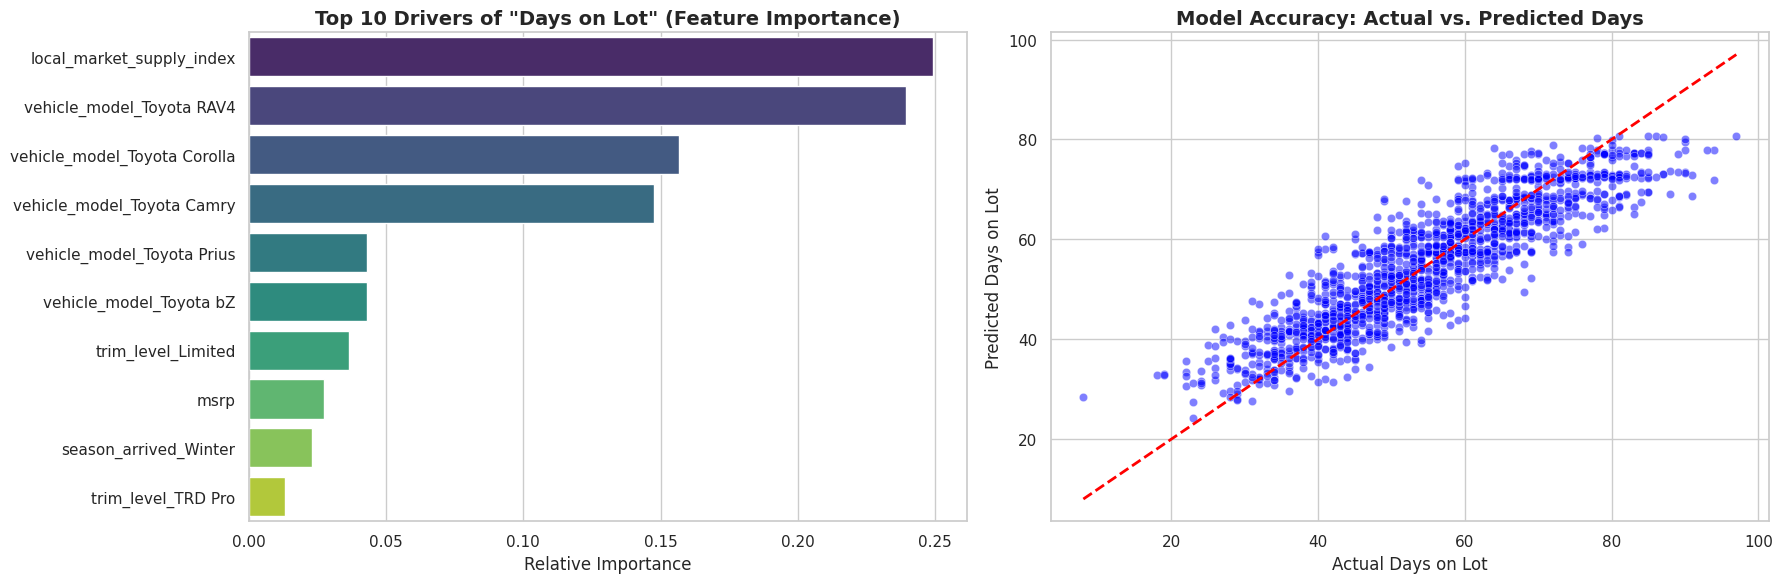

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_theme(style="whitegrid")

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ---------------------------------------------------------
# PLOT 1: Feature Importance (What drives Days on Lot?)
# ---------------------------------------------------------
# Extract feature importances from the Random Forest model
feature_importances = model.feature_importances_
features = X.columns

# Create a DataFrame for sorting and plotting
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(10) # Top 10 features

sns.barplot(x='Importance', y='Feature', data=importance_df, ax=axes[0], palette="viridis", hue='Feature', legend=False)
axes[0].set_title('Top 10 Drivers of "Days on Lot" (Feature Importance)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Relative Importance')
axes[0].set_ylabel('')

# ---------------------------------------------------------
# PLOT 2: Actual vs. Predicted Days on Lot
# ---------------------------------------------------------
# A scatter plot to visualize how close our predictions are to reality
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, color='blue', ax=axes[1])

# Draw the "Perfect Prediction" diagonal line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[1].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)

axes[1].set_title('Model Accuracy: Actual vs. Predicted Days', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Actual Days on Lot')
axes[1].set_ylabel('Predicted Days on Lot')

plt.tight_layout()
plt.show()

### Conclusion & Next Steps

This pipeline successfully demonstrates how machine learning can transform inventory management from a reactive process into a proactive strategy. By predicting the exact number of days a vehicle will remain on the lot, supply chain operations can realize significant financial savings through targeted, data-driven interventions.

**Strategic Recommendations for Production:**
1. **Dynamic Pricing Integration:** Link the output of this model directly into the pricing engine to automatically adjust incentives based on the predicted dwell time.
2. **Logistics Rerouting:** Vehicles predicted to sit >60 days in a specific regional market could be automatically flagged for rerouting to regions with a lower `local_market_supply_index` before they even leave the port.
3. **Continuous Learning:** In a production environment, this Random Forest model should be retrained weekly as macroeconomic factors (interest rates, fuel prices) shift consumer demand.

### Appendix: Model Export for Production

In a real-world scenario, the trained model must be exported and handed off to software engineering teams to integrate into the live inventory management system (e.g., via a REST API).

In [ ]:
import joblib

# Export the trained Random Forest model
model_filename = 'inventory_velocity_rf_model.pkl'
joblib.dump(model, model_filename)

print(f"✅ Model successfully exported as '{model_filename}'")
print("Status: Ready for deployment to production API.")

✅ Model successfully exported as 'inventory_velocity_rf_model.pkl'
Status: Ready for deployment to production API.
